# Baseline CNN + BiGRU Seizure Detector
**Architecture:** 3-layer 1D CNN 2-layer Bidirectional GRU, Sigmoid  
**Loss:** Focal Loss  
**Evaluation:** Sensitivity, Precision, F1, FP/hour, Temporal Accuracy

In [29]:
import os, sys, time, json, warnings, yaml, logging
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(message)s')

# ── Make src/ importable from notebooks/ ───────────────────────────────────
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve)

# ── NeuroScribe src imports ─────────────────────────────────────────────────
from src.data.dataset import EEGDataset, build_train_loader, build_eval_loader, build_split_dataset
from src.models.cnn_gru import CNNGRUClassifier
from src.models.losses import FocalLoss
from src.training.trainer import run_epoch

sns.set_theme(style='darkgrid'); plt.rcParams['figure.dpi'] = 100

RESULTS_DIR   = '../results/baseline1'
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED        = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# Hyperparameters
BATCH_SIZE  = 256
LR          = 1e-4
MAX_EPOCHS  = 30
PATIENCE    = 10
FOCAL_ALPHA = 0.85
FOCAL_GAMMA = 2.0
FS          = 256
WINDOW_SEC  = 4
OVERLAP_DS  = 0.0          # no overlap — avoids disk quota issues
STEP_SEC    = WINDOW_SEC   # step = full window when overlap=0

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Results: {os.path.abspath(RESULTS_DIR)}')


Device : cuda
GPU    : NVIDIA RTX 6000 Ada Generation
Results: /home/stu15/s0/cm7513/NeuroScribe-EEG-Seizure-Detection-with-Evidence-Grounded-Clinical-Reporting/results/baseline1


---
## 1. Load Preprocessed Data

In [33]:
# ── Build splits directly from raw EDF files (no .npz cache needed) ────────
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

RAW_DIR         = cfg['data']['raw_dir']
TARGET_CHANNELS = cfg['data']['channels']

print('Building splits from raw EDF files...')
print('(This takes ~25-40 min — channel mismatch warnings are normal)')
print()

train_ds = build_split_dataset(
    raw_dir=RAW_DIR, patient_ids=list(range(1, 19)), split_name='train',
    target_channels=TARGET_CHANNELS, window_size_sec=WINDOW_SEC,
    overlap=OVERLAP_DS, sample_rate=FS, processed_dir=None, use_cache=False,
)
val_ds = build_split_dataset(
    raw_dir=RAW_DIR, patient_ids=[19, 20, 21], split_name='val',
    target_channels=TARGET_CHANNELS, window_size_sec=WINDOW_SEC,
    overlap=OVERLAP_DS, sample_rate=FS, processed_dir=None, use_cache=False,
)
test_ds = build_split_dataset(
    raw_dir=RAW_DIR, patient_ids=[22, 23, 24], split_name='test',
    target_channels=TARGET_CHANNELS, window_size_sec=WINDOW_SEC,
    overlap=OVERLAP_DS, sample_rate=FS, processed_dir=None, use_cache=False,
)

N_CHANNELS = train_ds.windows.shape[1]
print(f'Channels: {N_CHANNELS}  |  Window samples: {train_ds.windows.shape[2]}')
print(f'  train → {len(train_ds):,} windows  seizure: {train_ds.n_seizure:,} ({train_ds.seizure_fraction:.2%})')
print(f'  val   → {len(val_ds):,} windows  seizure: {val_ds.n_seizure:,} ({val_ds.seizure_fraction:.2%})')
print(f'  test  → {len(test_ds):,} windows  seizure: {test_ds.n_seizure:,} ({test_ds.seizure_fraction:.2%})')


Patient chb01: 42 recordings, 7 with seizures, 7 total seizures
chb01: 42 files, 7 seizures


Building splits from raw EDF files...
(This takes ~25-40 min — channel mismatch warnings are normal)



Patient chb02: 36 recordings, 2 with seizures, 2 total seizures
chb02: 36 files, 2 seizures
Patient chb03: 38 recordings, 7 with seizures, 7 total seizures
chb03: 38 files, 7 seizures
Patient chb04: 42 recordings, 3 with seizures, 4 total seizures
chb04: 42 files, 4 seizures
Patient chb05: 39 recordings, 5 with seizures, 5 total seizures
chb05: 39 files, 5 seizures
Patient chb06: 18 recordings, 7 with seizures, 10 total seizures
chb06: 18 files, 10 seizures
Patient chb07: 19 recordings, 3 with seizures, 3 total seizures
chb07: 19 files, 3 seizures
Patient chb08: 20 recordings, 5 with seizures, 5 total seizures
chb08: 20 files, 5 seizures
Seizure 2 has start but no end — skipping
Expected 2 seizures, parsed 1
Patient chb09: 19 recordings, 3 with seizures, 3 total seizures
chb09: 19 files, 3 seizures
Patient chb10: 25 recordings, 7 with seizures, 7 total seizures
chb10: 25 files, 7 seizures
Patient chb11: 35 recordings, 3 with seizures, 3 total seizures
chb11: 35 files, 3 seizures
Patien

Channels: 23  |  Window samples: 1024
  train → 704,679 windows  seizure: 3,842 (0.55%)
  val   → 80,421 windows  seizure: 183 (0.23%)
  test  → 70,968 windows  seizure: 257 (0.36%)


In [38]:
def stratified_subsample(ds, max_nonsiezure, seed=42):
    np.random.seed(seed)
    seizure_idx    = np.where(ds.labels == 1)[0]
    nonseizure_idx = np.where(ds.labels == 0)[0]
    
    n_nonsiezure = min(max_nonsiezure, len(nonseizure_idx))
    sampled_ns   = np.random.choice(nonseizure_idx, n_nonsiezure, replace=False)
    idx          = np.concatenate([seizure_idx, sampled_ns])
    np.random.shuffle(idx)
    
    return EEGDataset(ds.windows[idx], ds.labels[idx], ds.patient_ids[idx])

# Keep all seizures + 10x non-seizure windows
train_ds = stratified_subsample(train_ds, len(np.where(train_ds.labels==1)[0]) * 5)
val_ds   = stratified_subsample(val_ds,   len(np.where(val_ds.labels==1)[0])   * 5)
test_ds  = stratified_subsample(test_ds,  len(np.where(test_ds.labels==1)[0])  * 5)

print(f'Train: {len(train_ds):,}  seizure: {train_ds.n_seizure:,} ({train_ds.seizure_fraction:.2%})')
print(f'Val  : {len(val_ds):,}  seizure: {val_ds.n_seizure:,} ({val_ds.seizure_fraction:.2%})')
print(f'Test : {len(test_ds):,}  seizure: {test_ds.n_seizure:,} ({test_ds.seizure_fraction:.2%})')

Train: 23,052  seizure: 3,842 (16.67%)
Val  : 1,098  seizure: 183 (16.67%)
Test : 1,542  seizure: 257 (16.67%)


---
## 2. Model Definition

In [39]:
model = CNNGRUClassifier(n_channels=N_CHANNELS, dropout = 0.5).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model      : CNNGRUClassifier  (src.models.cnn_gru)')
print(f'Parameters : {total_params:,}')
print(model)

Model      : CNNGRUClassifier  (src.models.cnn_gru)
Parameters : 2,123,649
CNNGRUClassifier(
  (cnn): Sequential(
    (0): CNNBlock(
      (block): Sequential(
        (0): Conv1d(23, 64, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): CNNBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): CNNBlock(
      (block): Sequential(
        (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, tra

---
## 3. Focal Loss & Optimiser

In [51]:
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
print('Loss      : FocalLoss(alpha=0.90, gamma=2.0)  (src.models.losses)')
print('Optimiser : Adam  lr=3e-4  wd=1e-4')

Loss      : FocalLoss(alpha=0.90, gamma=2.0)  (src.models.losses)
Optimiser : Adam  lr=3e-4  wd=1e-4


---
## 4. Training Loop

In [52]:
history   = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_val_f1 = 0.0
best_ckpt   = os.path.join(RESULTS_DIR, 'best_model.pt')
no_improve  = 0

print(f'Training for up to {MAX_EPOCHS} epochs (early stop patience={PATIENCE})\n')
print(f'  {"Epoch":>5} | {"Train Loss":>10} | {"Train F1":>9} | {"Val Loss":>9} | {"Val F1":>8} | {"Sens":>7} | {"Prec":>7}')
print('  ' + '-'*72)

for epoch in range(1, MAX_EPOCHS + 1):
    t_res = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=DEVICE)
    v_res = run_epoch(model, val_loader,   criterion, device=DEVICE)

    history['train_loss'].append(t_res['loss'])
    history['val_loss'].append(v_res['loss'])
    history['train_f1'].append(t_res['f1'])
    history['val_f1'].append(v_res['f1'])

    scheduler.step(v_res['f1'])

    marker = ''
    if v_res['f1'] > best_val_f1:
        best_val_f1 = v_res['f1']
        torch.save(model.state_dict(), best_ckpt)
        no_improve = 0
        marker = ' - '
    else:
        no_improve += 1

    print(f'  {epoch:>5} | {t_res["loss"]:>10.4f} | {t_res["f1"]:>9.4f} | '
          f'{v_res["loss"]:>9.4f} | {v_res["f1"]:>8.4f} | '
          f'{v_res["sensitivity"]:>7.4f} | {v_res["precision"]:>7.4f}{marker}')

    if no_improve >= PATIENCE:
        print(f'\n  Early stop at epoch {epoch} (no val F1 improvement for {PATIENCE} epochs)')
        break

print(f'\nBest val F1: {best_val_f1:.4f}  ,  saved to {best_ckpt}')

Training for up to 30 epochs (early stop patience=10)

  Epoch | Train Loss |  Train F1 |  Val Loss |   Val F1 |    Sens |    Prec
  ------------------------------------------------------------------------
      1 |     0.0049 |    0.9740 |    0.0373 |   0.2484 |  0.8415 |  0.1457 - 
      2 |     0.0051 |    0.9743 |    0.0251 |   0.2845 |  0.7486 |  0.1756 - 
      3 |     0.0050 |    0.9749 |    0.0316 |   0.3750 |  0.5738 |  0.2785 - 
      4 |     0.0042 |    0.9782 |    0.0422 |   0.3736 |  0.2787 |  0.5667
      5 |     0.0035 |    0.9826 |    0.0398 |   0.4185 |  0.4208 |  0.4162 - 
      6 |     0.0034 |    0.9836 |    0.0314 |   0.3245 |  0.7049 |  0.2108
      7 |     0.0035 |    0.9828 |    0.0590 |   0.3571 |  0.2459 |  0.6522
      8 |     0.0030 |    0.9853 |    0.0610 |   0.2740 |  0.1639 |  0.8333
      9 |     0.0030 |    0.9856 |    0.1098 |   0.1031 |  0.0546 |  0.9091
     10 |     0.0024 |    0.9886 |    0.0720 |   0.2133 |  0.1311 |  0.5714
     11 |     0.0033 |

---
## 5. Training Curves

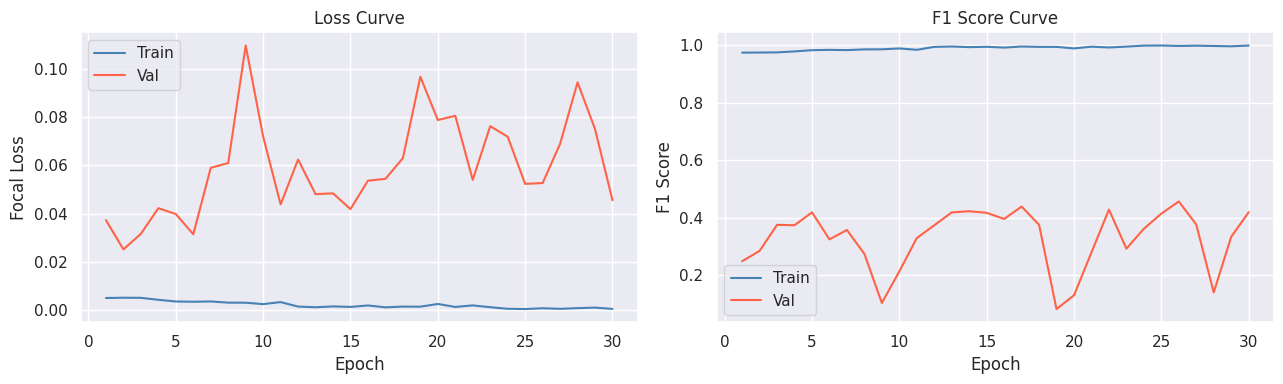

In [53]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss Curve'); axes[0].legend()

axes[1].plot(epochs, history['train_f1'], label='Train', color='steelblue')
axes[1].plot(epochs, history['val_f1'],   label='Val',   color='tomato')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Threshold Tuning on Validation Set

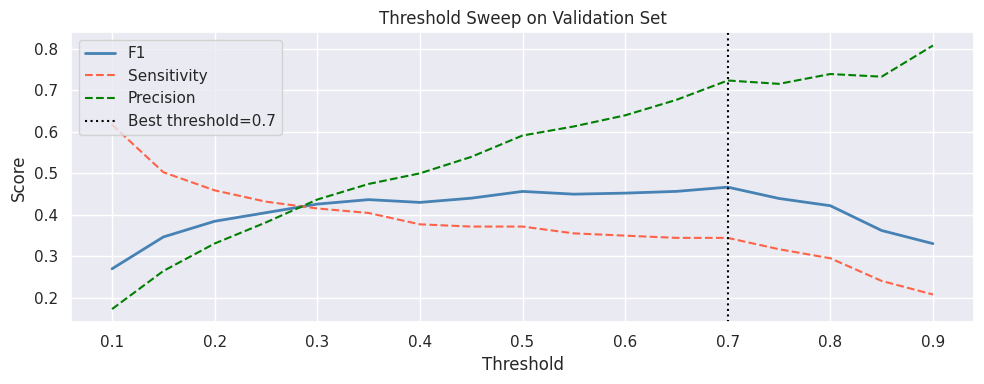

Best threshold: 0.7  ,  F1=0.4667  Sens=0.3443  Prec=0.7241


In [54]:
# Load best checkpoint
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

# Get val probabilities via src.training.trainer.run_epoch
val_res = run_epoch(model, val_loader, criterion, device=DEVICE, threshold=0.5)
val_probs, val_labels = val_res['probs'], val_res['labels']

# Sweep thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
thresh_rows = []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    tp = ((preds==1)&(val_labels==1)).sum()
    fp = ((preds==1)&(val_labels==0)).sum()
    fn = ((preds==0)&(val_labels==1)).sum()
    sens = tp / max(tp+fn, 1)
    prec = tp / max(tp+fp, 1)
    f1   = 2*sens*prec / max(sens+prec, 1e-8)
    thresh_rows.append({'threshold': round(t,2), 'sensitivity': round(sens,4),
                        'precision': round(prec,4), 'f1': round(f1,4)})

df_thresh = pd.DataFrame(thresh_rows)
best_row  = df_thresh.loc[df_thresh['f1'].idxmax()]
BEST_THRESH = float(best_row['threshold'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_thresh['threshold'], df_thresh['f1'],          label='F1',          color='steelblue', lw=2)
ax.plot(df_thresh['threshold'], df_thresh['sensitivity'], label='Sensitivity',  color='tomato',    lw=1.5, linestyle='--')
ax.plot(df_thresh['threshold'], df_thresh['precision'],   label='Precision',    color='green',     lw=1.5, linestyle='--')
ax.axvline(BEST_THRESH, color='black', linestyle=':', label=f'Best threshold={BEST_THRESH}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sweep on Validation Set')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'threshold_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Best threshold: {BEST_THRESH}  ,  F1={best_row["f1"]:.4f}  '
      f'Sens={best_row["sensitivity"]:.4f}  Prec={best_row["precision"]:.4f}')

---
## 7. Evaluation on Test Set

In [55]:
test_res    = run_epoch(model, test_loader, criterion, device=DEVICE, threshold=BEST_THRESH)
test_probs  = test_res['probs']
test_labels = test_res['labels']
test_preds  = (test_probs >= BEST_THRESH).astype(int)

tp = ((test_preds==1)&(test_labels==1)).sum()
fp = ((test_preds==1)&(test_labels==0)).sum()
fn = ((test_preds==0)&(test_labels==1)).sum()
tn = ((test_preds==0)&(test_labels==0)).sum()

sensitivity = tp / max(tp+fn, 1)
precision   = tp / max(tp+fp, 1)
specificity = tn / max(tn+fp, 1)
f1          = 2*sensitivity*precision / max(sensitivity+precision, 1e-8)

# FP per hour: each step = STEP_SEC seconds
fp_per_hour = fp * STEP_SEC / 3600

metrics = {
    'Sensitivity (Recall)': round(sensitivity, 4),
    'Precision':            round(precision,   4),
    'Specificity':          round(specificity, 4),
    'F1 Score':             round(f1,          4),
    'FP / hour':            round(fp_per_hour, 2),
    'TP':  int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    'Threshold': BEST_THRESH,
}

print('\n' + '='*45)
print('TEST SET RESULTS - CNN+GRU Baseline')
print('='*45)
for k, v in metrics.items():
    print(f'  {k:<25} {v}')

# Save metrics
with open(os.path.join(RESULTS_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nSaved at {RESULTS_DIR}/metrics.json')


TEST SET RESULTS - CNN+GRU Baseline
  Sensitivity (Recall)      0.4163
  Precision                 0.5602
  Specificity               0.9837
  F1 Score                  0.4777
  FP / hour                 0.09
  TP                        107
  FP                        84
  FN                        150
  TN                        5056
  Threshold                 0.7

Saved at ../results/baseline1/metrics.json


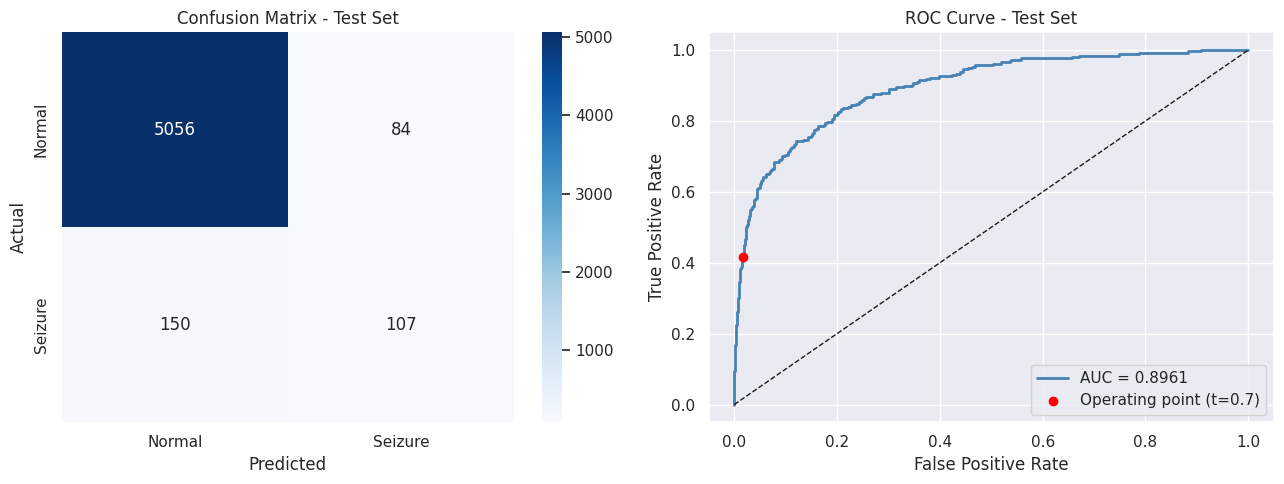

In [56]:
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Seizure'], yticklabels=['Normal','Seizure'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - Test Set')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].scatter([metrics['FP']/(metrics['FP']+metrics['TN'])],
                [sensitivity], color='red', zorder=5, label=f'Operating point (t={BEST_THRESH})')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

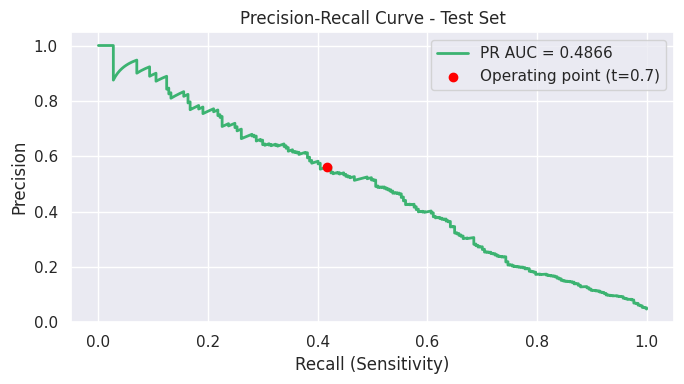

PR AUC: 0.4866


In [57]:
prec_curve, rec_curve, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(rec_curve, prec_curve)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rec_curve, prec_curve, color='mediumseagreen', lw=2, label=f'PR AUC = {pr_auc:.4f}')
ax.scatter([sensitivity], [precision], color='red', zorder=5,
           label=f'Operating point (t={BEST_THRESH})')
ax.set_xlabel('Recall (Sensitivity)'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Test Set')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pr_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'PR AUC: {pr_auc:.4f}')

In [58]:
patient_rows = []
unique_pids  = np.unique(pids_test)

for pid in unique_pids:
    mask = pids_test == pid
    pl, pp = test_labels[mask], test_preds[mask]
    tp_ = ((pp==1)&(pl==1)).sum()
    fp_ = ((pp==1)&(pl==0)).sum()
    fn_ = ((pp==0)&(pl==1)).sum()
    s_  = tp_ / max(tp_+fn_, 1)
    p_  = tp_ / max(tp_+fp_, 1)
    f_  = 2*s_*p_ / max(s_+p_, 1e-8)
    patient_rows.append({
        'Patient':     f'chb{pid:02d}',
        'Windows':     mask.sum(),
        'Sensitivity': round(s_, 4),
        'Precision':   round(p_, 4),
        'F1':          round(f_, 4),
        'FP/hour':     round(fp_ * STEP_SEC / 3600, 2),
    })

df_per_patient = pd.DataFrame(patient_rows)
print('Per-patient results:')
df_per_patient

Per-patient results:


,Patient,Windows,Sensitivity,Precision,F1,FP/hour
0,chb22,2101,0.2800,0.4375,0.3415,0.02
1,chb23,1881,0.4630,0.6024,0.5236,0.04
2,chb24,1415,0.4343,0.5658,0.4914,0.04


---
## 8. Final Results Summary

In [59]:
print('\n' + '='*50)
print('BASELINE 1 - CNN+GRU - FINAL RESULTS')
print('='*50)
print(f'  Model        : 3-layer 1D CNN + 2-layer BiGRU')
print(f'  Loss         : Focal Loss (Î±={FOCAL_ALPHA}, Î³={FOCAL_GAMMA})')
print(f'  Threshold    : {BEST_THRESH}')
print(f'  Split        : patient-independent (18/3/3)')
print()
print(f'  Sensitivity  : {sensitivity:.4f}  ({sensitivity*100:.1f}%)')
print(f'  Precision    : {precision:.4f}  ({precision*100:.1f}%)')
print(f'  F1 Score     : {f1:.4f}')
print(f'  Specificity  : {specificity:.4f}')
print(f'  FP / hour    : {fp_per_hour:.2f}')
print(f'  ROC AUC      : {roc_auc:.4f}')
print(f'  PR  AUC      : {pr_auc:.4f}')
print()
print(f'  Saved to: {os.path.abspath(RESULTS_DIR)}')
print('='*50)


BASELINE 1 - CNN+GRU - FINAL RESULTS
  Model        : 3-layer 1D CNN + 2-layer BiGRU
  Loss         : Focal Loss (Î±=0.85, Î³=2.0)
  Threshold    : 0.7
  Split        : patient-independent (18/3/3)

  Sensitivity  : 0.4163  (41.6%)
  Precision    : 0.5602  (56.0%)
  F1 Score     : 0.4777
  Specificity  : 0.9837
  FP / hour    : 0.09
  ROC AUC      : 0.8961
  PR  AUC      : 0.4866

  Saved to: /home/stu15/s0/cm7513/NeuroScribe-EEG-Seizure-Detection-with-Evidence-Grounded-Clinical-Reporting/results/baseline1
